In [1]:
n = 825
number_of_topics = 15
n_clusters = 16
clustering_method = "kmeans"
trained_topic_model_folder = "Subphenotyping-for-PASC_test/trained_topic_model_sinai_n825_v1"
print(f'results_sinai_n{n}_{number_of_topics}topics_{n_clusters}clusters_v{trained_topic_model_folder.split("_v")[-1]}')

results_sinai_n825_15topics_16clusters_v1


In [2]:
import numpy as np
import pandas as pd
import re
import os
import scipy.io as sio
import openpyxl
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

import sklearn.cluster
from sklearn import preprocessing
import umap

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import plotly.express as px
import plotly.graph_objects as go

In [3]:
file = f'{trained_topic_model_folder}/PFA_trained_model_n{n}_k{number_of_topics}.mat'
data = sio.loadmat(file) 
print(file)

surveys = pd.read_csv("data_cleaned/UCSF_2_4_25_most_recent_surveys_100_n825.csv")
del surveys["currentsymptoms_45"]
del surveys["currentsymptoms_46"]
surveys = surveys.rename(columns = {"comorb_selfreport_v2___13": "comorb_selfreport_13"})

colors = list(sns.color_palette("tab20"))
colors.extend(["purple", "black", "yellow", "green", "blue", "pink", "cyan", "cyan", "cyan"])

file_ = open('references/symptoms_sinai.txt','r')
symptoms = file_.readlines()[:44]
file_.close()
symptoms = [val.lower().replace("\n", "") for val in symptoms]
print(len(symptoms), "symptoms")

file_ = open('references/Neurological_Symptom_Mapping.txt','r')
mapping = [val.lower().replace("\n", "").replace("\t", "") for val in file_.readlines()]
file_.close()
neurologicals = [val.lower() for val in ["Neurological", "Cognitive/Psych", "Musculo-Skeletal", "G.I", "Sexual/Hormonal Function", "sensory changes", "temperature regulation", "pulmonary", "cardiovascular"]]
neurological_symptom_mapping, color_mapping, symptoms_ordered, symptoms_ordered_colors = {}, {}, [], []
curr, ct = "", -1
for val in mapping: 
    val = val.replace("\t", "")
    if val in neurologicals: 
        curr = val
        ct += 1
    else: 
        if val not in symptoms: 
            if val == "abnormal changes in body temp": val = "Abnormal changes in body temperature".lower()
            elif val == "unexplained sweats or flushin": val = "Unexplained sweats or flushing".lower()
        symptoms_ordered.append(val)
        symptoms_ordered_colors.append(colors[ct])
        color_mapping[curr] = colors[ct]
        if curr not in list(neurological_symptom_mapping.keys()): neurological_symptom_mapping[curr] = [val]
        else: neurological_symptom_mapping[curr].append(val)
print(len(neurological_symptom_mapping.keys()),  "symptom groups")

# comorb_selfreport_1	comorb_selfreport_2	comorb_selfreport_3	comorb_selfreport_4	comorb_selfreport_5	comorb_selfreport_6	comorb_selfreport_7	comorb_selfreport_8	comorb_selfreport_9	comorb_selfreport_10	comorb_selfreport_11	comorb_selfreport_12	comorb_selfreport_v2___13	comorb_selfreport_14	comorb_selfreport_15	comorb_selfreport_16	comorb_selfreport_17	comorb_selfreport_18	comorb_selfreport_19	comorb_selfreport_20
comorb = ["Hypertension", "Diabetes", "Chronic Kidney Disease", "Chronic Liver Disease (i.e Cirrhosis, Hepatitis B)", "Asthma", "Chronic Obstructive Pulmonary Disease", "Other Chronic Lung Disease", "Stroke", "Spinal Cord Injury", "Other Neurological Disease (Parkinson, Epilepsy, Dementia)", "Obesity", "Immunodeficiency (i.e auto-immune disease)", "Cancer", "Anxiety", "Depression", "Other Psychiatric Disease", "Eating disorder", "Inflammatory Bowel Disease/ Irritable Bowel Syndrome", "Other - please specify below", "None"]
comorb_dict = dict(zip(["comorb_selfreport_" + str(i) for i in range(1, len(comorb) + 1)], comorb))
# comorb_dict

def get_clusters(method, n_clusters, topic_proportions): 
    method = method.lower()
    if method == "kmeans": 
        clusters = sklearn.cluster.KMeans(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "minibatch": 
        clusters = sklearn.cluster.MiniBatchKMeans(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "spectralclustering": 
        clusters = sklearn.cluster.SpectralClustering(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "birch": 
        clusters = sklearn.cluster.Birch(n_clusters = n_clusters).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "agglomerativeclustering": 
        clusters = sklearn.cluster.AgglomerativeClustering(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "bisectingkmeans": 
        clusters = sklearn.cluster.BisectingKMeans(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    # Sorting by cluster sizes
    dictionary = sorted(dict(Counter(clusters)).items(), key=lambda x:x[1])
    dictionary.reverse()
    # [(1, 183), (3, 94), (5, 88), (9, 68), (2, 59), (8, 52), (7, 50), (4, 39), (6, 36)]
    mapping = dict(zip([val[0] for val in dictionary], np.unique(clusters))) # new:original
    # {1: 1, 3: 2, 5: 3, 9: 4, 2: 5, 8: 6, 7: 7, 4: 8, 6: 9}
    clusters = [mapping[val] for val in clusters]
    df = pd.DataFrame()
    df[0] = clusters
    dictionary = sorted(dict(Counter(clusters)).items(), key=lambda x:x[1])
    dictionary.reverse()
    return clusters

def plot_clusters(clusters, embedding, title, colors, topic_proportions_, highlights): 
    plt.figure()
    fig, ax = plt.subplots()
    plt.title(title)
    legend_elements = [] 
    for i in np.unique(clusters):
        a = plt.scatter(embedding[clusters==i, 0], embedding[clusters==i, 1], c = colors[i], s = 5)
        label = f"C{i}: {dict(Counter(clusters))[i]}"
        legend_elements.append(Line2D([0], [0], label = label, markerfacecolor = colors[i], markersize = 5, marker = 'o', color = 'w'))
        if highlights: 
            indeces = topic_proportions_[topic_proportions_["cluster"] == i].index
            indeces = list(set(indeces) & set(patients))
            a = plt.scatter(embedding[indeces, 0], embedding[indeces, 1], c = colors[i], s = 100, alpha = 0.5, marker = "^")
    ax.legend(handles = legend_elements, bbox_to_anchor=(1, 1))

Subphenotyping-for-PASC_test/trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat
44 symptoms
9 symptom groups


# Topic Matrix Heatmap

44 symptoms 15 topics
T1    1.0
T2    1.0
T3    1.0
dtype: float64
headache                                     0.766789
problems seeing (double or blurry vision)    0.267707
difficulty swallowing                        0.081071
dtype: float64
trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


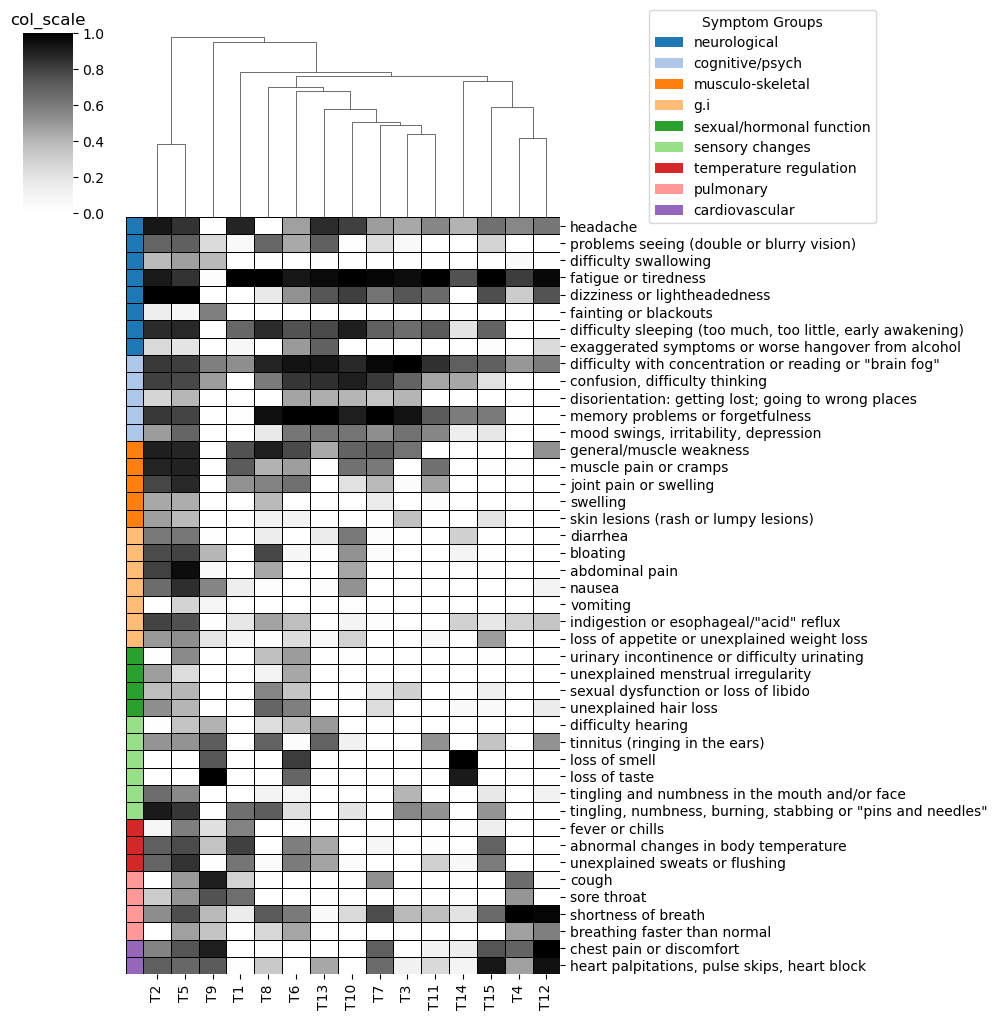

In [4]:
topic_matrix = pd.DataFrame(data['Phi_mean'])
print(topic_matrix.shape[0], "symptoms", topic_matrix.shape[1], "topics")
topic_matrix.columns = ["T" + str(val) for val in range(1, topic_matrix.shape[1] + 1)]
topic_matrix.index = pd.CategoricalIndex(symptoms, categories = symptoms_ordered)
topic_matrix = topic_matrix.sort_index()
# topic_matrix = topic_matrix.div(topic_matrix.sum(axis=1), axis=0) #### row-wise normalizing
print(topic_matrix.sum(0)[:3])
print(topic_matrix.sum(1)[:3])
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
handles = [Patch(facecolor=color_mapping[key]) for key in color_mapping.keys()]
plt.legend(handles, color_mapping, title='Symptom Groups',
           bbox_to_anchor=(0.88, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("col_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


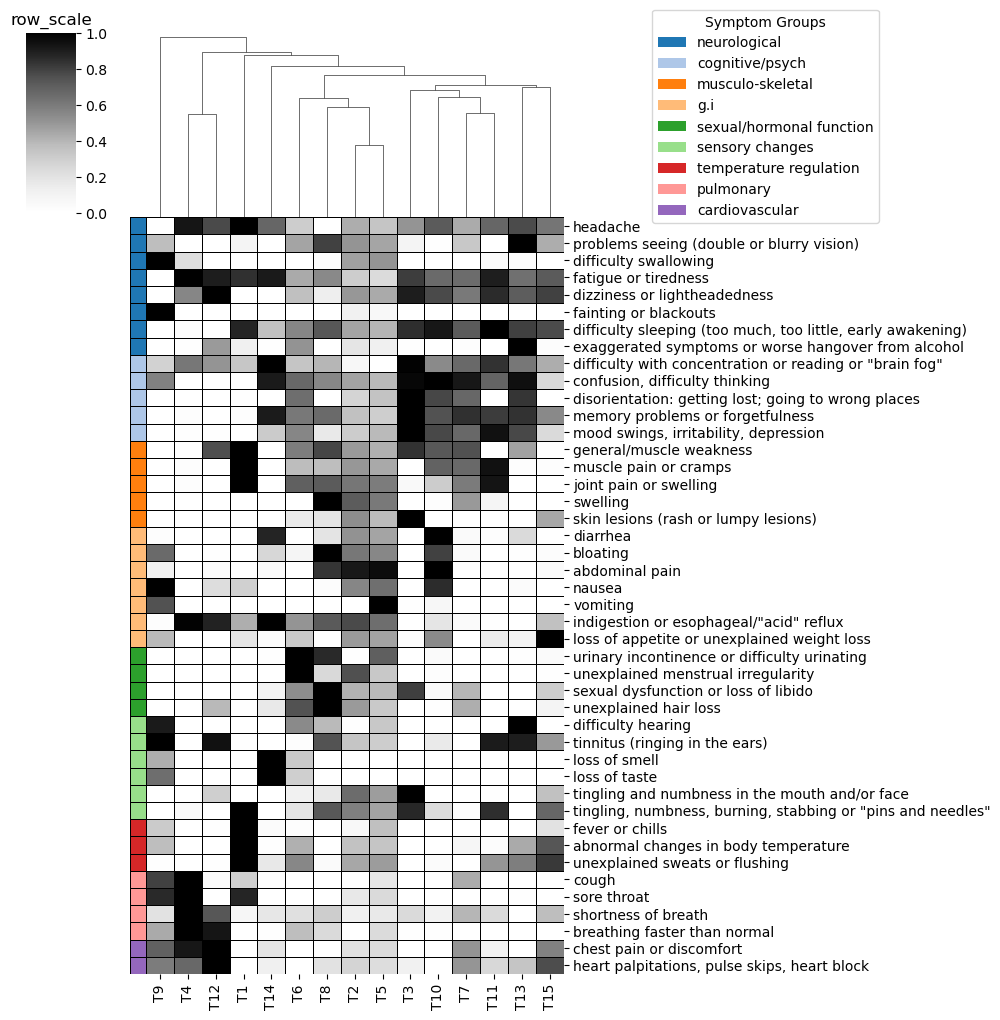

In [5]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
handles = [Patch(facecolor=color_mapping[key]) for key in color_mapping.keys()]
plt.legend(handles, color_mapping, title='Symptom Groups',
           bbox_to_anchor=(0.88, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


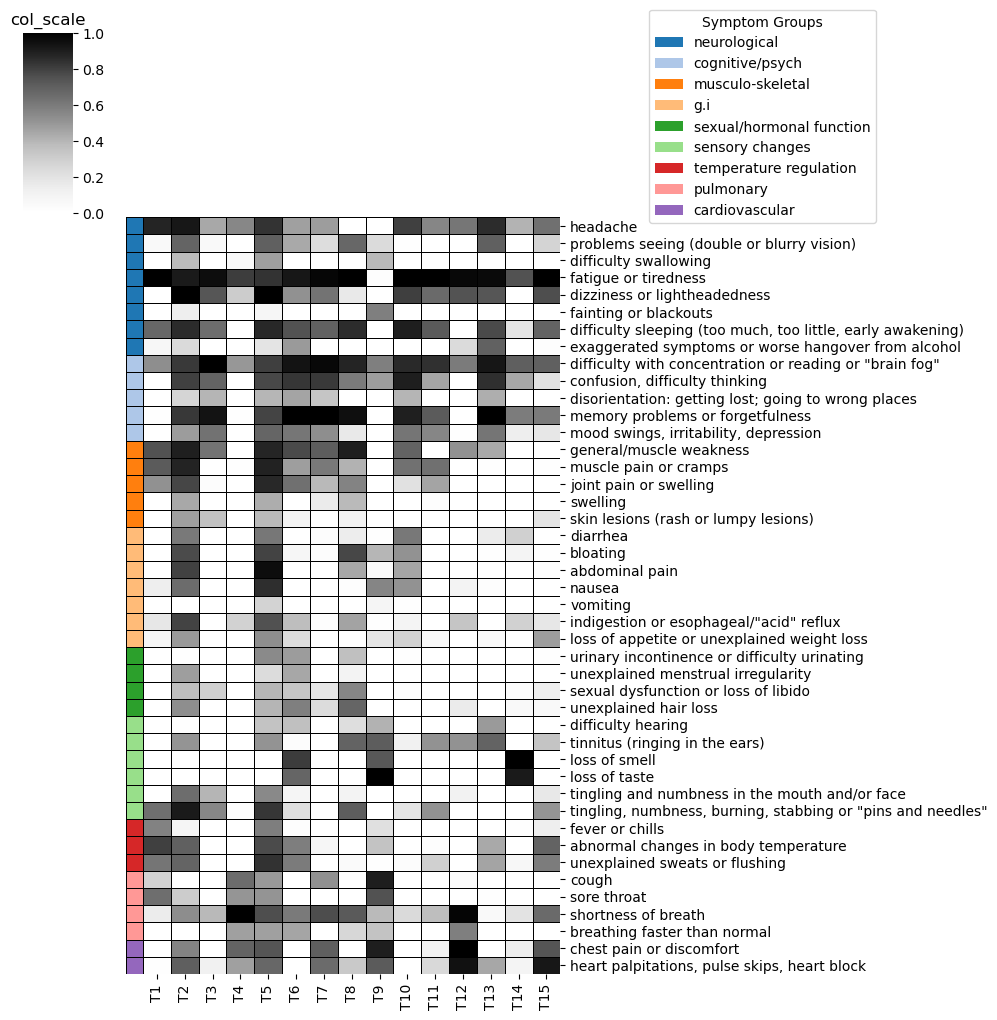

In [6]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
handles = [Patch(facecolor=color_mapping[key]) for key in color_mapping.keys()]
plt.legend(handles, color_mapping, title='Symptom Groups',
           bbox_to_anchor=(0.88, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("col_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


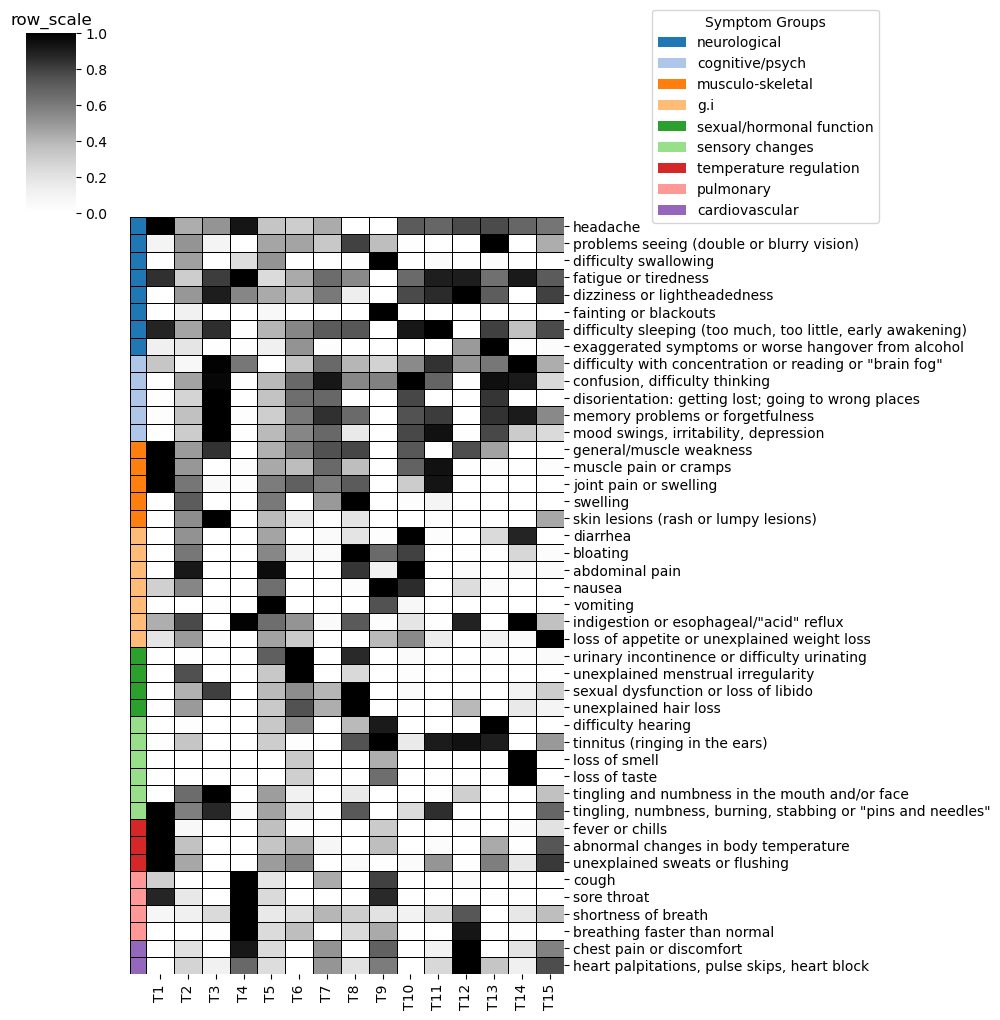

In [7]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
handles = [Patch(facecolor=color_mapping[key]) for key in color_mapping.keys()]
plt.legend(handles, color_mapping, title='Symptom Groups',
           bbox_to_anchor=(0.88, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


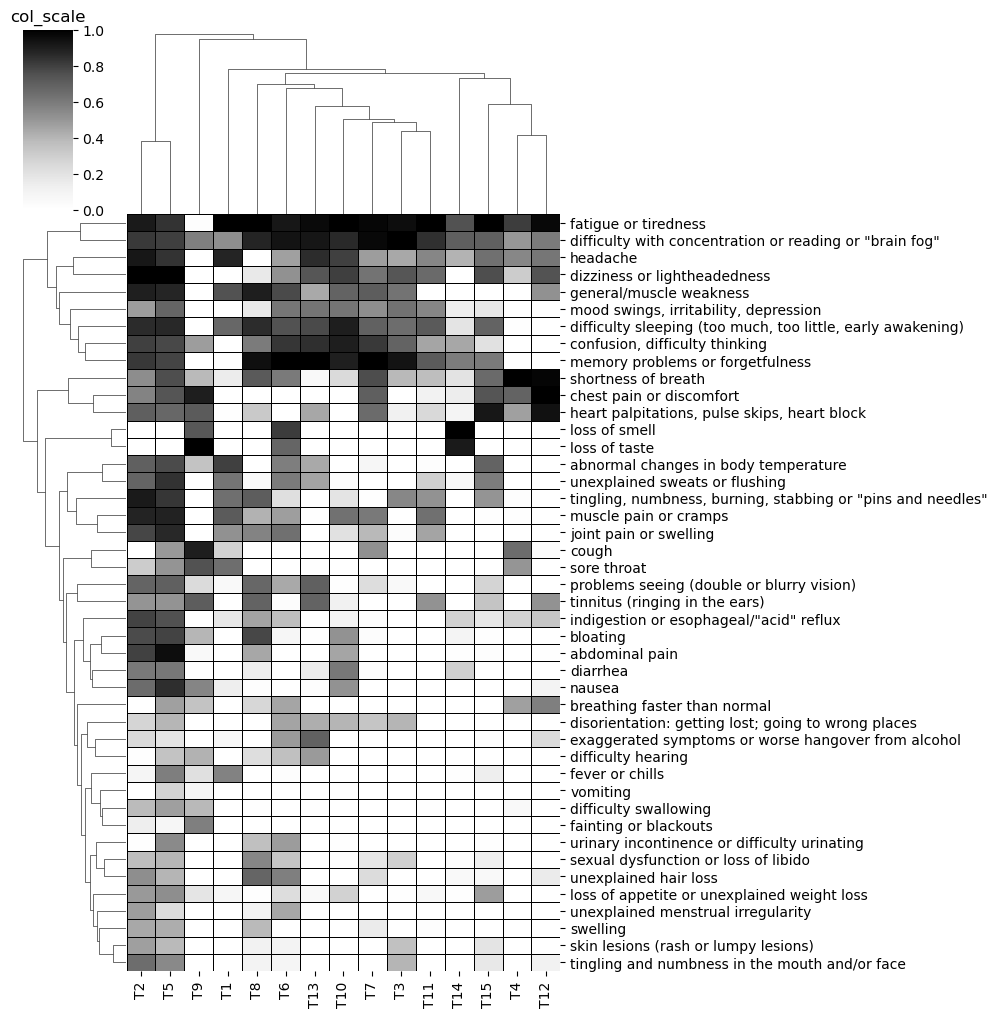

In [8]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = True, row_cluster = True, #row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("col_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


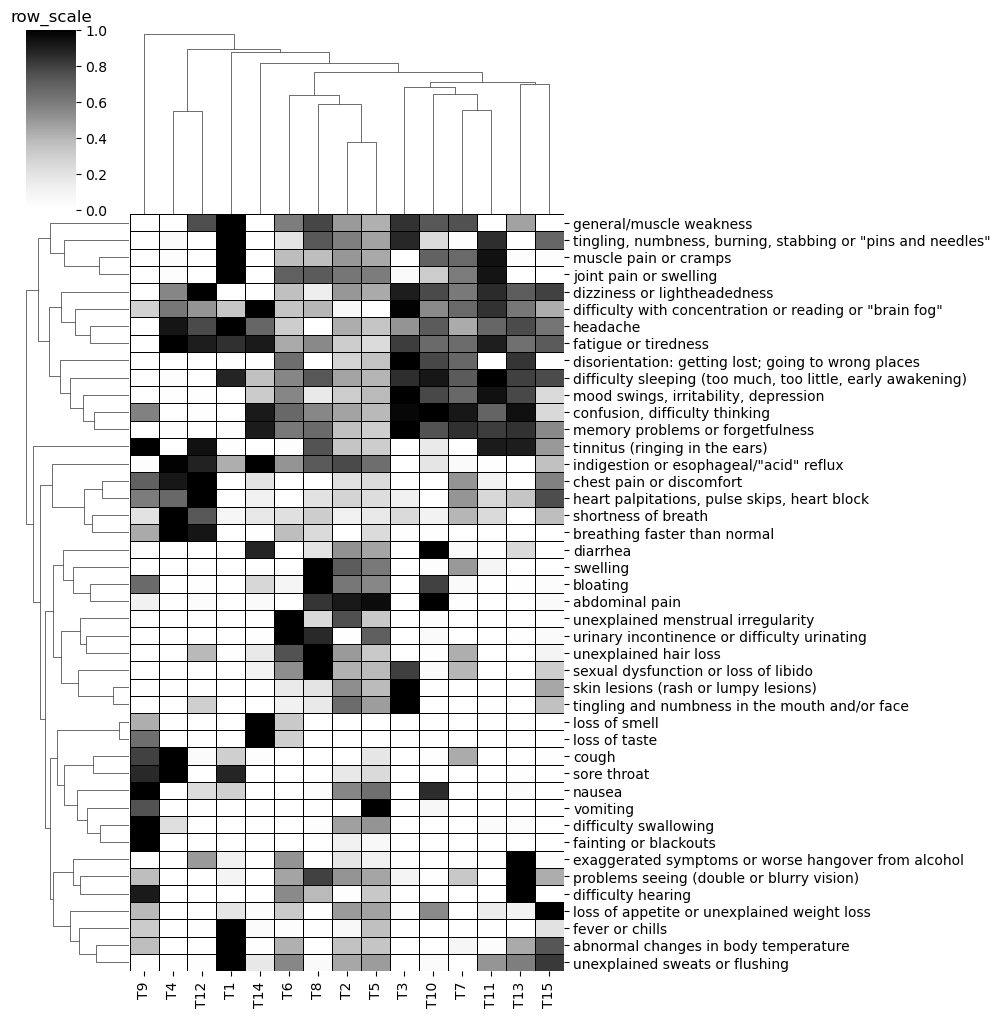

In [9]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = True, row_cluster = True, #row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

# Clustering

Counter({1: 300, 2: 103, 3: 54, 4: 48, 5: 44, 6: 35, 8: 34, 7: 34, 9: 31, 10: 28, 11: 27, 12: 26, 14: 19, 13: 19, 15: 13, 16: 10})
trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


<Figure size 640x480 with 0 Axes>

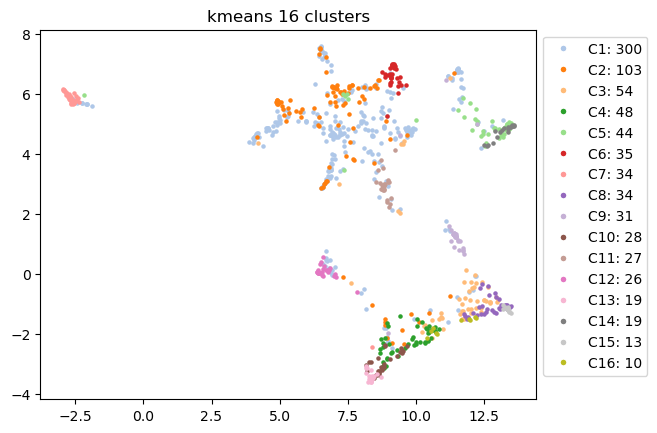

In [10]:
topic_proportions = pd.DataFrame(data['Theta_mean']).T
topic_proportions_norm = topic_proportions/topic_proportions.sum(1)[:,np.newaxis]
topic_proportions_norm = preprocessing.normalize(topic_proportions)
UMAP = umap.UMAP(metric='euclidean', n_neighbors=30, random_state=916)
embedding = UMAP.fit_transform(topic_proportions_norm)
clusters = get_clusters(clustering_method, n_clusters, topic_proportions)
topic_proportions_ = pd.DataFrame(topic_proportions).copy()
topic_proportions_["cluster"] = clusters
print(Counter(clusters))
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')
plot_clusters(clusters, embedding, f"{clustering_method} {n_clusters} clusters", colors, None, None)

<Figure size 640x480 with 0 Axes>

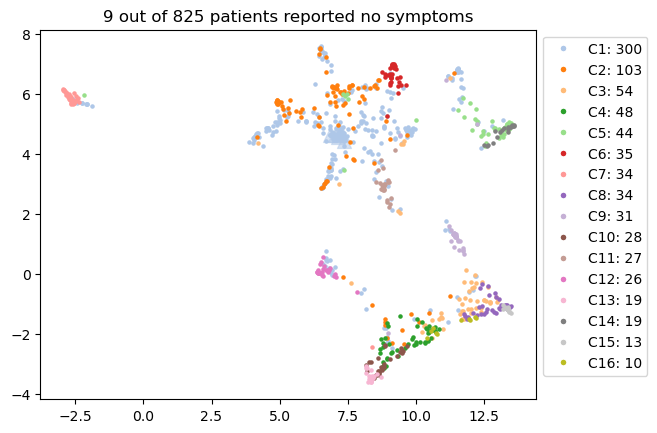

In [11]:
# Highlighting specific patients
title = "reported no symptoms"
patients = surveys[list(filter(re.compile("currentsymptoms_.*").match, surveys.columns))]
patients = list(patients[patients.sum(axis = 1) == 0.0].index)
plot_clusters(clusters, embedding, f"{len(patients)} out of {len(embedding)} patients {title}", colors, topic_proportions_, patients)

In [12]:
conditions = surveys.copy()
conditions["cluster"] = ["C" + str(c) for c in clusters]
dictionary = dict(conditions["cluster"].value_counts())
df = pd.DataFrame({"cluster": dictionary.keys(), "total": dictionary.values()})
df = df.sort_values(["total", "cluster"], ascending = [False, True])
for condition in comorb_dict.keys(): 
    patients = list(conditions[conditions[condition] == 1.0].index)
    dictionary = dict(conditions.iloc[patients, :]["cluster"].value_counts())
    df2 = pd.DataFrame({"cluster": list(dictionary.keys()), comorb_dict[condition]: list(dictionary.values())})
    df = df.merge(df2, on = "cluster", how = "outer")
    df["proportion_" + comorb_dict[condition]] = df[comorb_dict[condition]] / df["total"]
# df.to_csv("comorb_proportions_sinai.csv", index = False)
df

,cluster,total,Hypertension,proportion_Hypertension,Diabetes,proportion_Diabetes,Chronic Kidney Disease,proportion_Chronic Kidney Disease,"Chronic Liver Disease (i.e Cirrhosis, Hepatitis B)","proportion_Chronic Liver Disease (i.e Cirrhosis, Hepatitis B)",Asthma,proportion_Asthma,Chronic Obstructive Pulmonary Disease,proportion_Chronic Obstructive Pulmonary Disease,Other Chronic Lung Disease,proportion_Other Chronic Lung Disease,Stroke,proportion_Stroke,Spinal Cord Injury,proportion_Spinal Cord Injury,"Other Neurological Disease (Parkinson, Epilepsy, Dementia)","proportion_Other Neurological Disease (Parkinson, Epilepsy, Dementia)",Obesity,proportion_Obesity,Immunodeficiency (i.e auto-immune disease),proportion_Immunodeficiency (i.e auto-immune disease),Cancer,proportion_Cancer,Anxiety,proportion_Anxiety,Depression,proportion_Depression,Other Psychiatric Disease,proportion_Other Psychiatric Disease,Eating disorder,proportion_Eating disorder,Inflammatory Bowel Disease/ Irritable Bowel Syndrome,proportion_Inflammatory Bowel Disease/ Irritable Bowel Syndrome,Other - please specify below,proportion_Other - please specify below,None,proportion_None
0,C1,300,28.0,0.093333,7.0,0.023333,NaN,NaN,NaN,NaN,34,0.113333,NaN,NaN,NaN,NaN,3.0,0.010000,2.0,0.006667,5.0,0.016667,14.0,0.046667,17.0,0.056667,18.0,0.060000,49,0.163333,38,0.126667,5.0,0.016667,4.0,0.013333,18.0,0.060000,44,0.146667,81.0,0.270000
1,C2,103,8.0,0.077670,3.0,0.029126,1.0,0.009709,NaN,NaN,16,0.155340,NaN,NaN,1.0,0.009709,NaN,NaN,NaN,NaN,1.0,0.009709,1.0,0.009709,3.0,0.029126,1.0,0.009709,22,0.213592,15,0.145631,5.0,0.048544,1.0,0.009709,7.0,0.067961,17,0.165049,19.0,0.184466
2,C3,54,3.0,0.055556,NaN,NaN,1.0,0.018519,NaN,NaN,10,0.185185,NaN,NaN,1.0,0.018519,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0.055556,3.0,0.055556,2.0,0.037037,10,0.185185,9,0.166667,1.0,0.018519,1.0,0.018519,8.0,0.148148,14,0.259259,15.0,0.277778
3,C4,48,3.0,0.062500,2.0,0.041667,1.0,0.020833,NaN,NaN,11,0.229167,1.0,0.020833,NaN,NaN,NaN,NaN,1.0,0.020833,5.0,0.104167,4.0,0.083333,10.0,0.208333,1.0,0.020833,12,0.250000,12,0.250000,NaN,NaN,1.0,0.020833,5.0,0.104167,18,0.375000,6.0,0.125000
4,C5,44,8.0,0.181818,1.0,0.022727,NaN,NaN,NaN,NaN,6,0.136364,1.0,0.022727,NaN,NaN,NaN,NaN,1.0,0.022727,NaN,NaN,3.0,0.068182,3.0,0.068182,2.0,0.045455,18,0.409091,15,0.340909,3.0,0.068182,1.0,0.022727,9.0,0.204545,7,0.159091,6.0,0.136364
5,C6,35,2.0,0.057143,2.0,0.057143,1.0,0.028571,NaN,NaN,9,0.257143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.057143,3.0,0.085714,3.0,0.085714,10,0.285714,8,0.228571,NaN,NaN,1.0,0.028571,3.0,0.085714,8,0.228571,7.0,0.200000
6,C7,34,3.0,0.088235,1.0,0.029412,NaN,NaN,1.0,0.029412,9,0.264706,NaN,NaN,NaN,NaN,1.0,0.029412,1.0,0.029412,1.0,0.029412,NaN,NaN,NaN,NaN,9.0,0.264706,2,0.058824,2,0.058824,NaN,NaN,NaN,NaN,NaN,NaN,3,0.088235,3.0,0.088235
7,C8,34,1.0,0.029412,1.0,0.029412,NaN,NaN,NaN,NaN,6,0.176471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.029412,3.0,0.088235,1.0,0.029412,1.0,0.029412,10,0.294118,3,0.088235,NaN,NaN,NaN,NaN,8.0,0.235294,15,0.441176,4.0,0.117647
8,C9,31,4.0,0.129032,1.0,0.032258,NaN,NaN,NaN,NaN,3,0.096774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0.096774,2.0,0.064516,3.0,0.096774,8,0.258065,6,0.193548,2.0,0.064516,NaN,NaN,4.0,0.129032,9,0.290323,6.0,0.193548
9,C10,28,1.0,0.035714,NaN,NaN,1.0,0.035714,1.0,0.035714,3,0.107143,NaN,NaN,1.0,0.035714,NaN,NaN,1.0,0.035714,NaN,NaN,4.0,0.142857,2.0,0.071429,NaN,NaN,7,0.250000,7,0.250000,1.0,0.035714,3.0,0.107143,2.0,0.071429,7,0.250000,4.0,0.142857


In [13]:
# # Highlighting specific conditions
# condition = "comorb_selfreport_1"
# if "comorb_" in condition: title = comorb_dict[condition]
# else: title = condition
# patients = list(surveys[surveys[condition] == 1.0].index)
# print(surveys[condition].value_counts())
# plot_clusters(clusters, embedding, f"{len(patients)} out of {len(embedding)} patients with {title}", colors, topic_proportions_, patients)

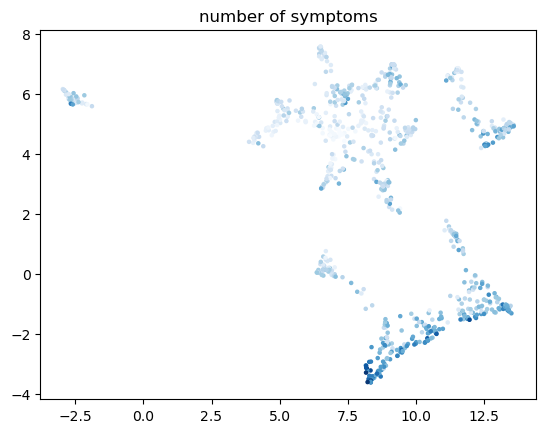

In [14]:
# Colored based on number of symptoms
plt.figure()
conditions = surveys[list(filter(re.compile("currentsymptoms_.*").match, surveys.columns))]
conditions["all"] = conditions.sum(axis = 1)
a = plt.scatter(embedding[:, 0], embedding[:, 1], c = conditions["all"], cmap = "Blues", s = 5)
a = plt.title("number of symptoms")

# Topic Proportions by Cluster

In [15]:
topic_proportions = pd.DataFrame(data['Theta_mean'].T)
topic_proportions.columns = ["T" + str(val) for val in range(1, topic_proportions.shape[1] + 1)]
topic_proportions_ = topic_proportions.copy()
topic_proportions_["cluster"] = clusters
topic_proportions_bycluster = topic_proportions_.groupby("cluster").mean()
topic_proportions_bycluster.index = ["C" + str(val) for val in topic_proportions_bycluster.index]
topic_proportions_bycluster = topic_proportions_bycluster.T
print(topic_proportions_bycluster.shape[0], "topics",  topic_proportions_bycluster.shape[1], "clusters", topic_proportions.shape[0], "patients")
# topic_proportions_bycluster = topic_proportions_bycluster.div(topic_proportions_bycluster.sum(axis=1), axis=0) #### row-wise normalizing
# topic_proportions_bycluster = topic_proportions_bycluster.div(topic_proportions_bycluster.sum(axis=0), axis=1) #### column-wise normalizing
print(topic_proportions_bycluster.sum(0)[:3])
print(topic_proportions_bycluster.sum(1)[:3])

15 topics 16 clusters 825 patients
C1     6.692116
C2    13.061505
C3    15.607701
dtype: float64
T1     8.213443
T2    58.404981
T3     9.399055
dtype: float64


trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


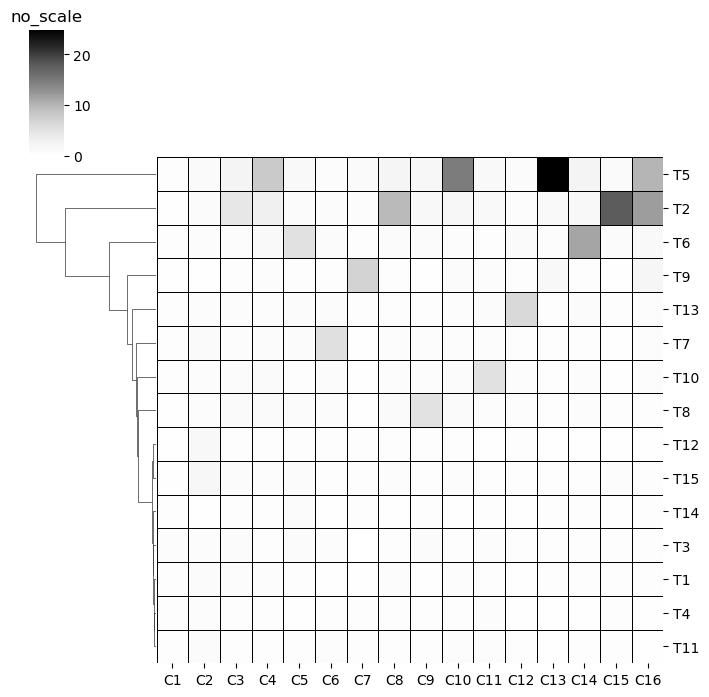

In [16]:
ax = sns.clustermap(topic_proportions_bycluster, vmin = 0, col_cluster = False, row_cluster = True, figsize = (7, 7), 
#                     standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.title("no_scale") # None
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=0, size = 10)
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


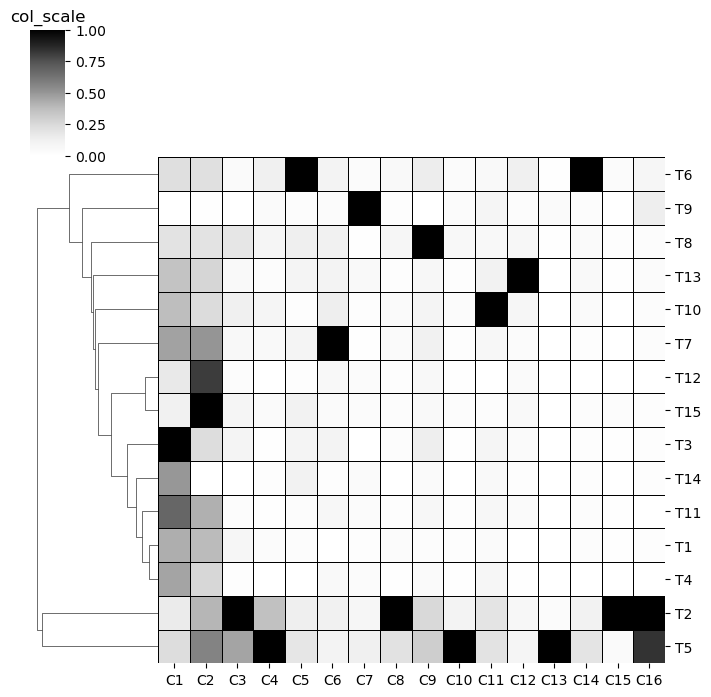

In [17]:
ax = sns.clustermap(topic_proportions_bycluster, vmin = 0, col_cluster = False, row_cluster = True, figsize = (7, 7), 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.title("col_scale") # 1
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=0, size = 10)
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


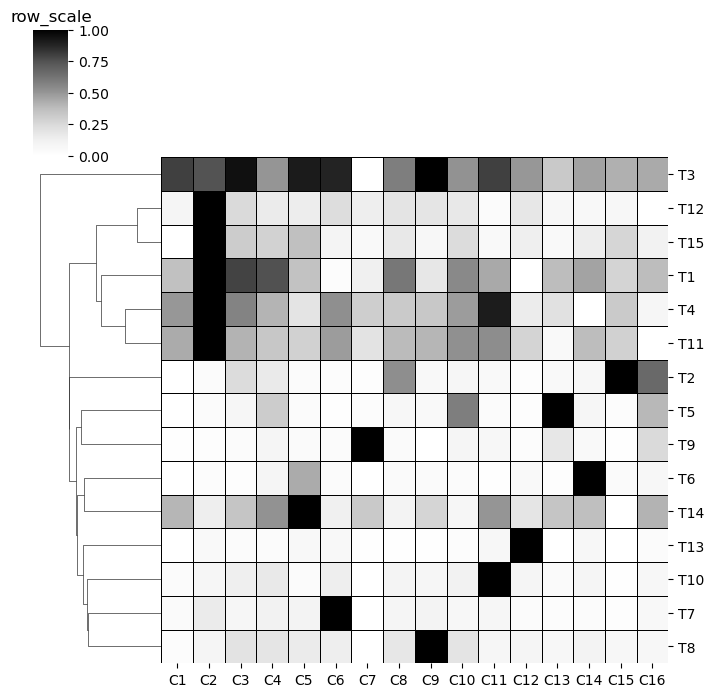

In [18]:
ax = sns.clustermap(topic_proportions_bycluster, vmin = 0, col_cluster = False, row_cluster = True, figsize = (7, 7), 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.title("row_scale") # 0
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=0, size = 10)
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

# Cluster by Symptom Heatmap

In [19]:
cluster_by_symptom = pd.DataFrame(np.dot(topic_matrix, topic_proportions_bycluster))
print(cluster_by_symptom.shape, "=", topic_matrix.shape, "x", topic_proportions_bycluster.shape)
cluster_by_symptom.index = topic_matrix.index
cluster_by_symptom.columns = ["C" + str(val) for val in range(1, cluster_by_symptom.shape[1] + 1)]
# cluster_by_symptom = cluster_by_symptom.div(cluster_by_symptom.sum(axis=1), axis=0) #### row-wise normalizing
# cluster_by_symptom = cluster_by_symptom.div(cluster_by_symptom.sum(axis=0), axis=1) #### column-wise normalizing
print(cluster_by_symptom.sum(0)[:3])
print(cluster_by_symptom.sum(1)[:3])

(44, 16) = (44, 15) x (15, 16)
C1     6.692116
C2    13.061505
C3    15.607701
dtype: float64
headache                                     12.223125
problems seeing (double or blurry vision)     7.123843
difficulty swallowing                         2.967936
dtype: float64


trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


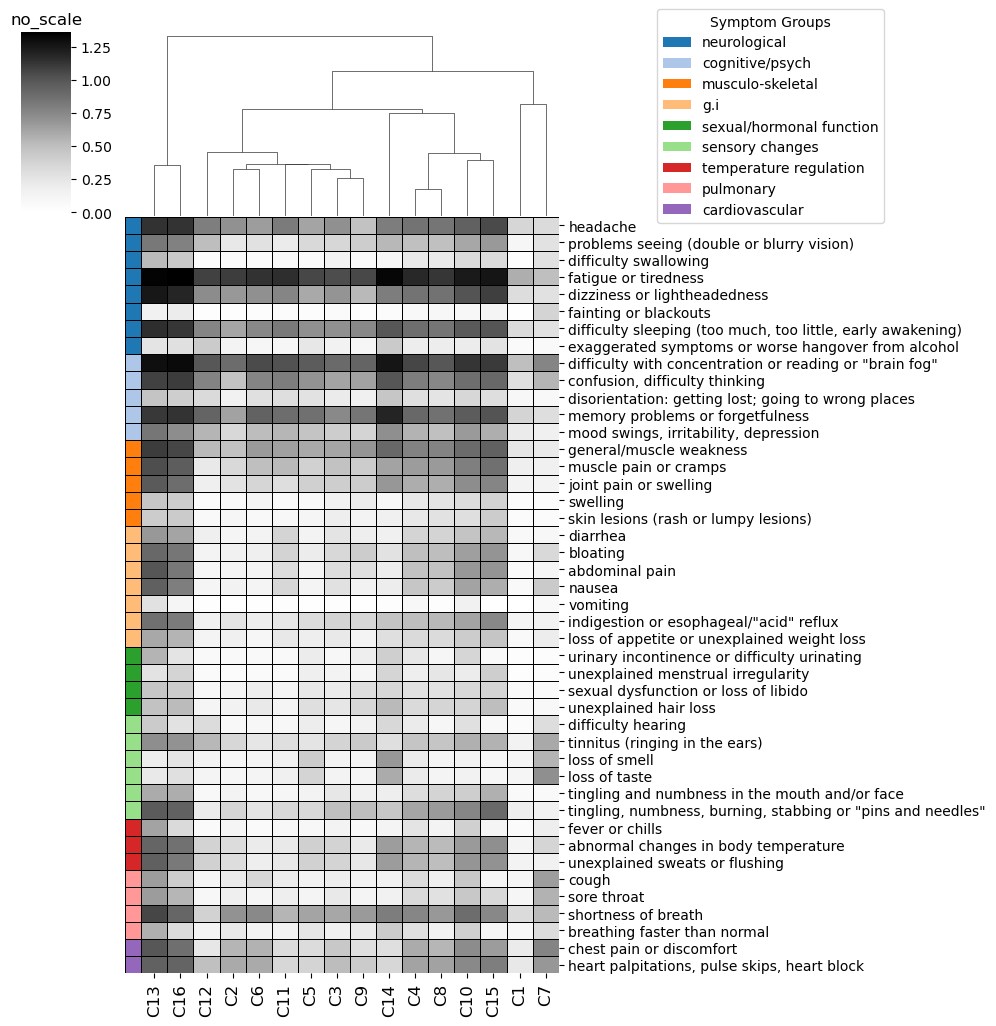

In [20]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
#                     standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("no_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


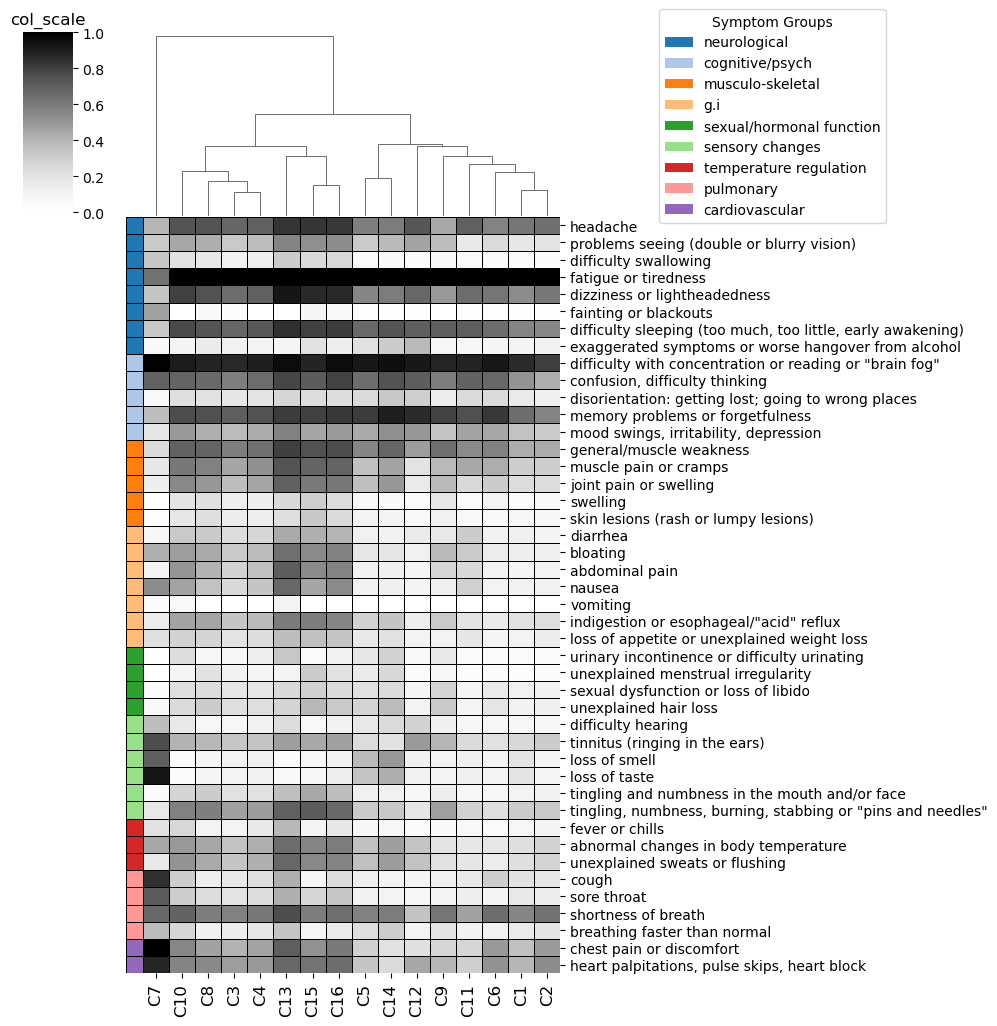

In [21]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("col_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


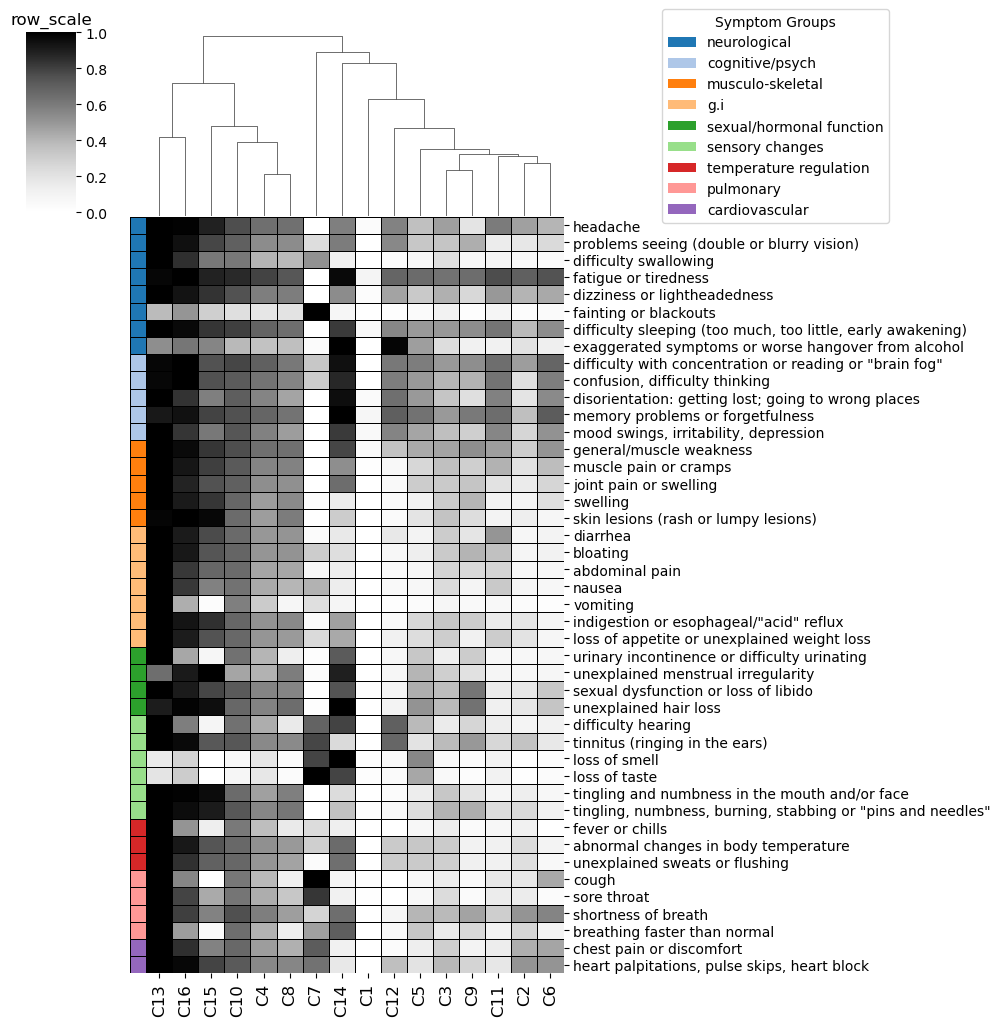

In [22]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


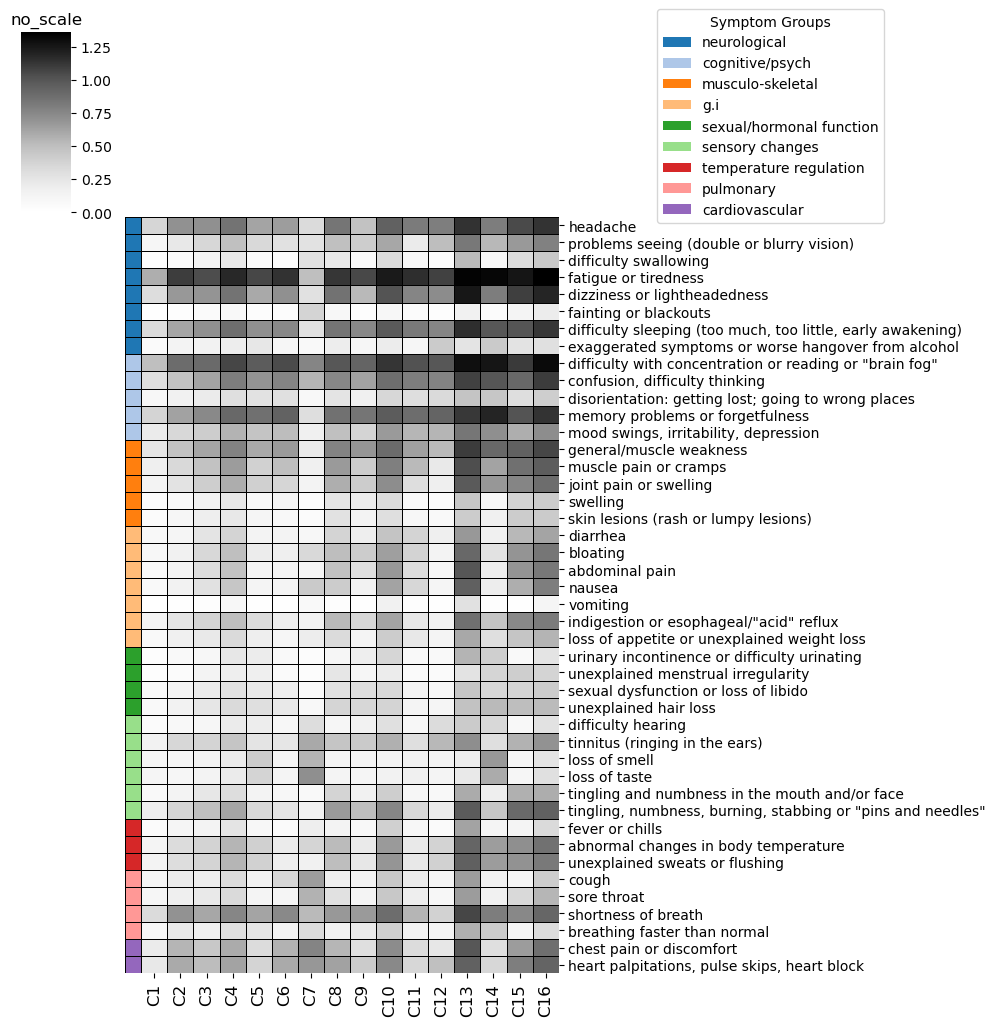

In [23]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
#                     standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("no_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


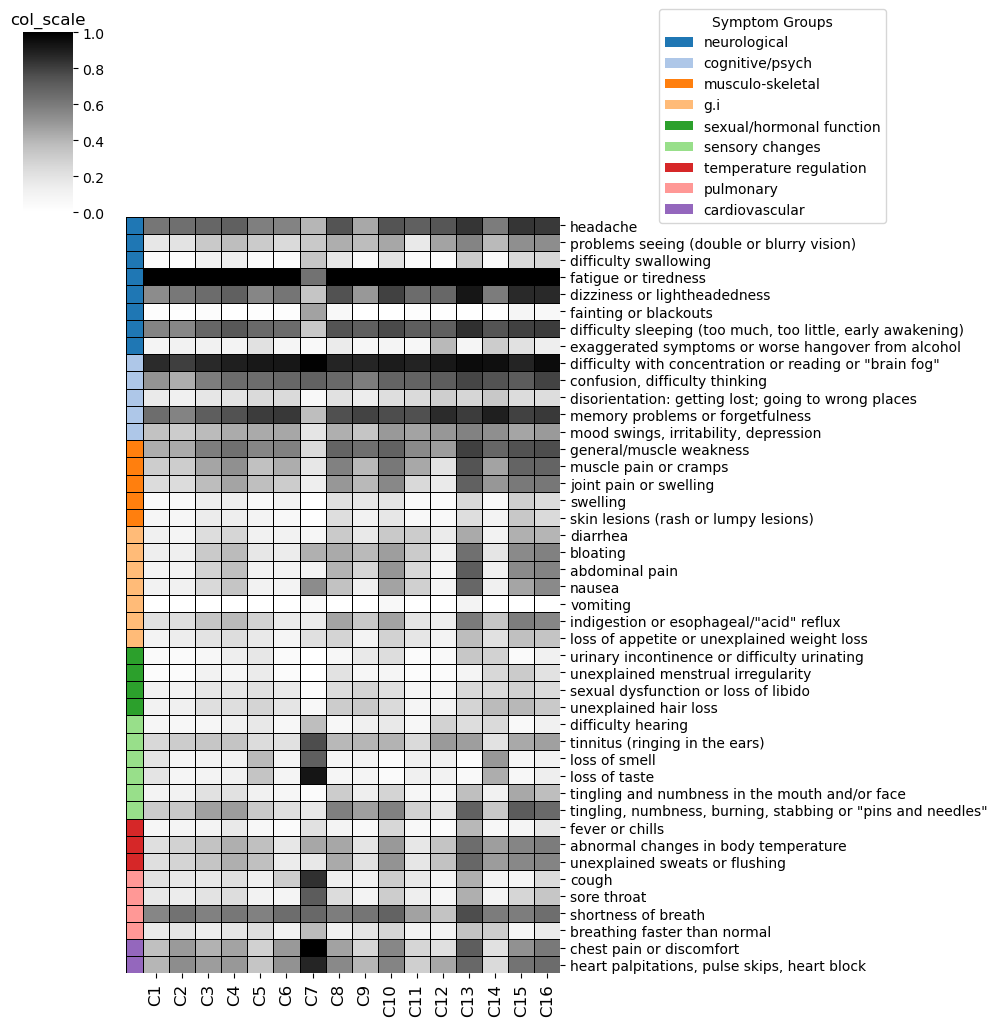

In [24]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("col_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


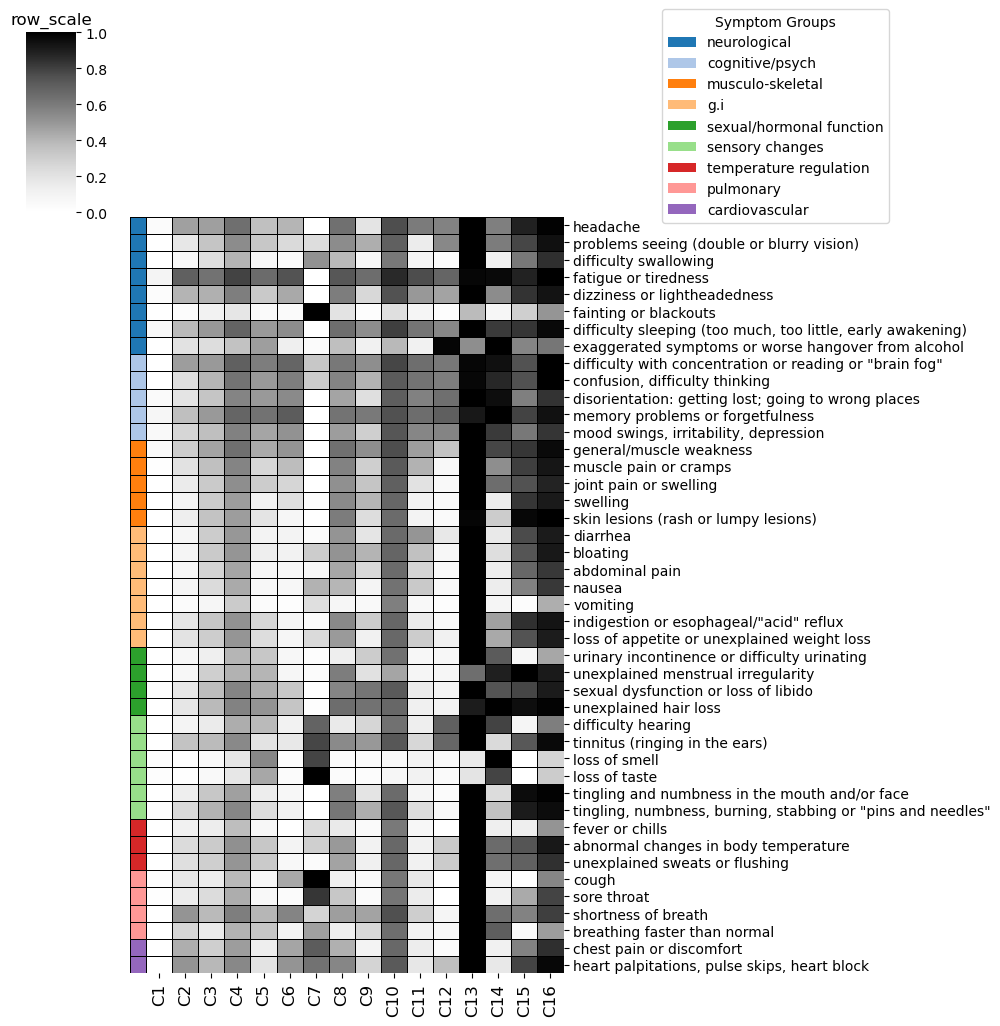

In [25]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

# Defining symptom severity groups

In [26]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# https://github.com/mwaskom/seaborn/blob/86b5481ca47cb46d3b3e079a5ed9b9fb46e315ef/seaborn/matrix.py#L892

# Standardize the data
standardized = cluster_by_symptom.copy().T
subtract = standardized.min()
standardized = (standardized - subtract) / (standardized.max() - standardized.min())
standardized = standardized.T

# # Plotting to check same as sns.clustermap standard_scaling
# ax = sns.clustermap(standardized, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
# #                     standard_scale = 0, 
#                     xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
#                     cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)

standardized

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16
headache,0.036659,0.466377,0.469710,0.640224,0.362057,0.398958,0.000000,0.633792,0.188753,0.758655,0.594070,0.572780,1.000000,0.580183,0.889432,0.991967
problems seeing (double or blurry vision),0.000000,0.171945,0.340685,0.535510,0.331350,0.248609,0.229615,0.536126,0.423596,0.696174,0.145897,0.549694,1.000000,0.593400,0.783504,0.944654
difficulty swallowing,0.000000,0.057403,0.216902,0.405210,0.063403,0.043250,0.514354,0.390038,0.080924,0.607419,0.095669,0.038369,1.000000,0.128304,0.607427,0.846542
fatigue or tiredness,0.092626,0.697402,0.625302,0.790910,0.652756,0.742551,0.000000,0.729458,0.648397,0.860817,0.762458,0.676658,0.978162,0.965464,0.884089,1.000000
dizziness or lightheadedness,0.027907,0.403925,0.415429,0.582218,0.322687,0.439953,0.000000,0.586771,0.255050,0.747327,0.493568,0.459566,1.000000,0.535347,0.834526,0.936516
fainting or blackouts,0.000000,0.027279,0.105937,0.181248,0.045445,0.039775,1.000000,0.198235,0.015721,0.219168,0.083429,0.021558,0.381113,0.076816,0.296023,0.503542
"difficulty sleeping (too much, too little, early awakening)",0.058259,0.383612,0.493360,0.683990,0.491622,0.533719,0.000000,0.643287,0.534160,0.801179,0.621016,0.552001,1.000000,0.815648,0.828573,0.966204
exaggerated symptoms or worse hangover from alcohol,0.000000,0.199504,0.226739,0.352574,0.474986,0.132785,0.037045,0.365823,0.115176,0.390127,0.115572,0.984292,0.531023,1.000000,0.558856,0.614737
"difficulty with concentration or reading or ""brain fog""",0.000000,0.477921,0.491860,0.697826,0.586255,0.677586,0.328961,0.607605,0.530459,0.781820,0.643798,0.608640,0.977535,0.943820,0.749762,1.000000
"confusion, difficulty thinking",0.000000,0.222493,0.399428,0.621673,0.491490,0.584577,0.304787,0.566063,0.413322,0.718508,0.622306,0.588992,0.974856,0.868001,0.753483,1.000000


In [27]:
severity = pd.DataFrame(standardized.sum()).rename(columns = {0: "sum"})
severity

,sum
C1,0.572607
C2,9.499710
C3,13.557691
C4,21.746250
C5,13.127195
C6,11.187363
C7,11.558083
C8,19.682539
C9,12.191753
C10,28.129994


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[0.5726065071336295, 9.49970954926615, 13.557691072130757, 21.746249935635763, 13.12719484778733, 11.18736322586023, 11.558082777808707, 19.68253903448229, 12.191752568992774, 28.129994292303124, 11.921554769785446, 11.099659777241397, 40.632550336797316, 23.381971438683983, 27.177866695635146, 35.84838916360683]


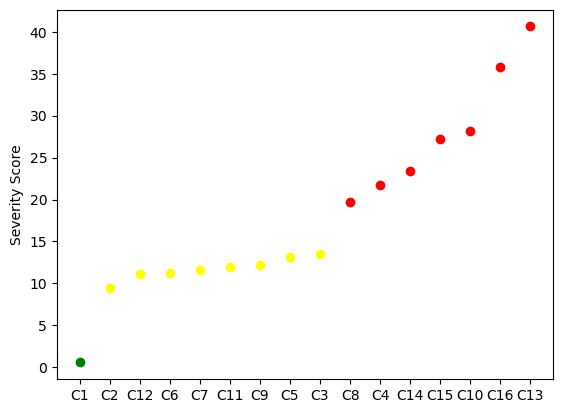

In [28]:
severity = pd.DataFrame(standardized.sum()).rename(columns = {0: "sum"}).reset_index()
severity["cluster"] = [int(val.replace("C", "")) for val in severity["index"]]
print(list(severity.index))
print(list(severity["sum"]))
severity = severity.sort_values("sum").reset_index()
colors = ["green"]
colors.extend(["yellow"]*8)
colors.extend(["red"]*7)
severity["color"] = colors
for index, row in severity.iterrows(): 
    a = plt.scatter([index], row["sum"], c = row["color"])
# a = plt.scatter(range(1, 17), severity["sum"])
a = plt.ylabel("Severity Score")
a = plt.xticks(range(0, severity.shape[0]), severity["index"])

# Star Charts per Cluster

In [29]:
patient_by_symptom = pd.DataFrame(np.dot(topic_matrix, topic_proportions.T))
print(patient_by_symptom.shape,  "=", topic_matrix.shape, "+", topic_proportions.T.shape)
patient_by_symptom.index = topic_matrix.index
patient_by_symptom = patient_by_symptom.T
# patient_by_symptom = patient_by_symptom.div(patient_by_symptom.sum(axis=1), axis=0) #### row-wise normalizing
# patient_by_symptom = patient_by_symptom.div(patient_by_symptom.sum(axis=0), axis=1) #### column-wise normalizing
print(patient_by_symptom.sum(0)[:3])
print(patient_by_symptom.sum(1)[:3])
patient_by_symptom["cluster"] = clusters
patient_by_symptom
df = pd.DataFrame()
cluster_by_symptom_norm = cluster_by_symptom.div(cluster_by_symptom.sum(axis=1), axis=0) #### row-wise normalizing
for col in cluster_by_symptom_norm.columns: 
    subset = cluster_by_symptom_norm[col].sort_values(ascending = False)
    df[col + "_sym"] = subset.index
    df[col + "_pro"] = [round(val, 3) for val in list(subset)]
columns = list(filter(re.compile(".*sym").match, df.columns))
cluster_topsymptoms = df[columns].copy()
cluster_topsymptoms.columns = [col.split("_")[0] for col in cluster_topsymptoms.columns]
cluster_topsymptoms = cluster_topsymptoms.iloc[:6, :]
cluster_topsymptoms.head(6)

(44, 825) = (44, 15) + (15, 825)
headache                                     494.847480
problems seeing (double or blurry vision)    240.840786
difficulty swallowing                         89.342181
dtype: float64
0     9.222579
1    10.215154
2    23.606646
dtype: float64


,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16
0,fatigue or tiredness,chest pain or discomfort,"tingling, numbness, burning, stabbing or ""pins...",vomiting,loss of smell,cough,fainting or blackouts,unexplained menstrual irregularity,sexual dysfunction or loss of libido,vomiting,diarrhea,exaggerated symptoms or worse hangover from al...,vomiting,loss of smell,unexplained menstrual irregularity,difficulty swallowing
1,loss of smell,"heart palpitations, pulse skips, heart block",fatigue or tiredness,fever or chills,loss of taste,memory problems or forgetfulness,loss of taste,tingling and numbness in the mouth and/or face,unexplained hair loss,fever or chills,disorientation: getting lost; going to wrong p...,difficulty hearing,fever or chills,loss of taste,tingling and numbness in the mouth and/or face,tingling and numbness in the mouth and/or face
2,loss of taste,shortness of breath,skin lesions (rash or lumpy lesions),urinary incontinence or difficulty urinating,exaggerated symptoms or worse hangover from al...,shortness of breath,loss of smell,skin lesions (rash or lumpy lesions),urinary incontinence or difficulty urinating,urinary incontinence or difficulty urinating,"mood swings, irritability, depression",tinnitus (ringing in the ears),urinary incontinence or difficulty urinating,urinary incontinence or difficulty urinating,skin lesions (rash or lumpy lesions),abdominal pain
3,"difficulty with concentration or reading or ""b...",fatigue or tiredness,headache,abdominal pain,urinary incontinence or difficulty urinating,chest pain or discomfort,cough,swelling,swelling,abdominal pain,headache,disorientation: getting lost; going to wrong p...,difficulty swallowing,exaggerated symptoms or worse hangover from al...,swelling,swelling
4,shortness of breath,headache,tingling and numbness in the mouth and/or face,swelling,unexplained menstrual irregularity,disorientation: getting lost; going to wrong p...,sore throat,"tingling, numbness, burning, stabbing or ""pins...",bloating,difficulty swallowing,"confusion, difficulty thinking",problems seeing (double or blurry vision),abdominal pain,unexplained menstrual irregularity,abdominal pain,skin lesions (rash or lumpy lesions)
5,headache,breathing faster than normal,"difficulty sleeping (too much, too little, ear...",nausea,breathing faster than normal,fatigue or tiredness,difficulty hearing,abdominal pain,"tingling, numbness, burning, stabbing or ""pins...",nausea,fatigue or tiredness,memory problems or forgetfulness,nausea,difficulty hearing,diarrhea,fainting or blackouts


In [30]:
dictionary = {}
for index, row in patient_by_symptom.iterrows(): 
    cluster = "C" + str(int(row["cluster"]))
    symptoms_subset = list(cluster_topsymptoms[cluster])[:6]
    symptoms_subset.append(symptoms_subset[0])
    values = [row[s] for s in symptoms_subset]
    values.append(values[0])
    dictionary[index] = dict(r = values, theta = symptoms_subset)
print(len(dictionary))
# dictionary

825


In [31]:
# Adding sexes if provided
print(dict(surveys["sex"].value_counts()))
# count_sex = {"rgba(0,255,0,0.25)": 0, "rgba(0,0,255,0.25)": 0, "rgba(50,50,50,0.25)": 0}
# count_sex = {"rgb(0,255,0)": 0, "rgb(0,0,255)": 0, "rgb(50,50,50)": 0}
count_sex = {"rgb(0,0,255)": 0, "rgb(255,0,0)": 0, "rgb(50,50,50)": 0}
values = []
for val in surveys["sex"]: 
#     print(val)
    if str(val) == "1.0" or str(val) == "M": # M
        values.append(list(count_sex.keys())[0])
    elif str(val) == "2.0" or str(val) == "F": # F
        values.append(list(count_sex.keys())[1])
    else: # else
        values.append(list(count_sex.keys())[2])
sexes = values[:]
print(len(sexes), Counter(sexes))

{'F': 566, 'M': 241}
825 Counter({'rgb(255,0,0)': 566, 'rgb(0,0,255)': 241, 'rgb(50,50,50)': 18})


In [32]:
def star_chart_per_patient(cluster): 
    scatterpolars = []
#     count_sex = {"rgba(0,255,0,0.75)": 0, "rgba(0,0,255,0.75)": 0, "rgba(50,50,50,0.25)": 0}
#     count_sex = {"rgb(0,255,0)": 0, "rgb(0,0,255)": 0, "rgb(50,50,50)": 0}
    count_sex = {"rgb(0,0,255)": 0, "rgb(255,0,0)": 0, "rgb(50,50,50)": 0}
    for i in list(patient_by_symptom[patient_by_symptom["cluster"] == cluster].index)[:]: 
        scatterpolars.append(go.Scatterpolar(dictionary[i], # fill = "toself", fillcolor = sexes[i], 
                                             mode = "lines",            
                                             name = "Patient" + str(i+1), 
                                             line_color = sexes[i], 
#                                              line = {"opacity": 0.25}, 
#                                              line_color = "rgba(100,25,25,0.25)", 
                                            ))
        count_sex[sexes[i]] += 1
    fig = go.Figure(data = scatterpolars)
    fig.update_traces(opacity = 0.25)
    # fig.update_polars(radialaxis=dict(range=[0, 1]))
    count_sex_str = str(count_sex).replace(list(count_sex.keys())[0], "M (blue)").replace(list(count_sex.keys())[1], "F (red)").replace(list(count_sex.keys())[2], "nan (gray)")
#     count_sex_str = ""
    fig.update_layout(title = ".\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\tCluster" + str(cluster) + ": " + str(len(scatterpolars)) + " patients " + count_sex_str)
    return fig

star_chart_per_patient(1)

In [33]:
star_chart_per_patient(2)

In [34]:
star_chart_per_patient(3)

In [35]:
star_chart_per_patient(4)

In [36]:
star_chart_per_patient(5)

In [37]:
star_chart_per_patient(6)

In [38]:
star_chart_per_patient(7)

In [39]:
star_chart_per_patient(8)

In [40]:
star_chart_per_patient(9)

In [41]:
star_chart_per_patient(10)

In [42]:
star_chart_per_patient(11)

In [43]:
star_chart_per_patient(12)

In [44]:
star_chart_per_patient(13)

In [45]:
star_chart_per_patient(14)

In [46]:
star_chart_per_patient(15)

In [47]:
star_chart_per_patient(16)

# Star Charts Median

In [48]:
def star_chart_median(cluster): 
    dictionary = {}
    symptoms_subset = list(cluster_topsymptoms["C" + str(cluster)])[:6]
    cluster_subset = patient_by_symptom[patient_by_symptom["cluster"] == cluster]
    cluster_subset["sex"] = surveys["sex"]
    for sex in ["F", "M"]: 
        cluster_sex_subset = cluster_subset[cluster_subset["sex"] == sex]
        cluster_sex_subset = cluster_sex_subset.median()[symptoms_subset]
        cluster_sex_subset = dict(cluster_sex_subset)
        key = f"{sex} (in cluster)"
        dictionary[key] = dict(r = list(cluster_sex_subset.values()), theta = list(cluster_sex_subset.keys()))
        dictionary[key]["r"].append(dictionary[key]["r"][0])
        dictionary[key]["theta"].append(dictionary[key]["theta"][0])
    cluster_subset = patient_by_symptom[patient_by_symptom["cluster"] != cluster]
    cluster_subset["sex"] = surveys["sex"]
    for sex in ["F", "M"]: 
        cluster_sex_subset = cluster_subset[cluster_subset["sex"] == sex]
        cluster_sex_subset = cluster_sex_subset.median()[symptoms_subset]
        cluster_sex_subset = dict(cluster_sex_subset)
        key = f"{sex} (global)"
        dictionary[key] = dict(r = list(cluster_sex_subset.values()), theta = list(cluster_sex_subset.keys()))
        dictionary[key]["r"].append(dictionary[key]["r"][0])
        dictionary[key]["theta"].append(dictionary[key]["theta"][0])

    scatterpolars = []
    scatterpolars.append(go.Scatterpolar(dictionary["F (in cluster)"], mode = "lines", 
                                         name = "F (in cluster)", line_color = "rgba(255,0,0,0.25)", ))
    scatterpolars.append(go.Scatterpolar(dictionary["M (in cluster)"], mode = "lines", 
                                         name = "M (in cluster)", line_color = "rgba(0,0,255,0.25)", ))
    scatterpolars.append(go.Scatterpolar(dictionary["F (global)"], mode = "lines", line = dict(dash = "dash"), 
                                         name = "F (global)", line_color = "rgba(255,0,0,0.25)", ))
    scatterpolars.append(go.Scatterpolar(dictionary["M (global)"], mode = "lines", line = dict(dash = "dash"), 
                                         name = "M (global)", line_color = "rgba(0,0,255,0.25)", ))
    fig = go.Figure(data = scatterpolars)
    count_sex_str = ""
    fig.update_layout(title = ".\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\tCluster" + str(cluster) + ": " + str(patient_by_symptom[patient_by_symptom["cluster"] == cluster].shape[0]) + " patients " + count_sex_str)
    return fig
star_chart_median(1)

In [49]:
star_chart_median(2)

In [50]:
star_chart_median(3)

In [51]:
star_chart_median(4)

In [52]:
star_chart_median(5)

In [53]:
star_chart_median(6)

In [54]:
star_chart_median(7)

In [55]:
star_chart_median(8)

In [56]:
star_chart_median(9)

In [57]:
star_chart_median(10)

In [58]:
star_chart_median(11)

In [59]:
star_chart_median(12)

In [60]:
star_chart_median(13)

In [61]:
star_chart_median(14)

In [62]:
star_chart_median(15)

In [63]:
star_chart_median(16)

# Getting endotypes

In [64]:
cluster_topsymptoms = cluster_topsymptoms.head(6)
cluster_topsymptoms_dict = {}
for col in cluster_topsymptoms.columns: 
    cluster_topsymptoms_dict[int(col.replace("C", ""))] = list(cluster_topsymptoms[col])
cluster_topsymptoms_dict

{1: ['fatigue or tiredness',
  'loss of smell',
  'loss of taste',
  'difficulty with concentration or reading or "brain fog"',
  'shortness of breath',
  'headache'],
 2: ['chest pain or discomfort',
  'heart palpitations, pulse skips, heart block',
  'shortness of breath',
  'fatigue or tiredness',
  'headache',
  'breathing faster than normal'],
 3: ['tingling, numbness, burning, stabbing or "pins and needles"',
  'fatigue or tiredness',
  'skin lesions (rash or lumpy lesions)',
  'headache',
  'tingling and numbness in the mouth and/or face',
  'difficulty sleeping (too much, too little, early awakening)'],
 4: ['vomiting',
  'fever or chills',
  'urinary incontinence or difficulty urinating',
  'abdominal pain',
  'swelling',
  'nausea'],
 5: ['loss of smell',
  'loss of taste',
  'exaggerated symptoms or worse hangover from alcohol',
  'urinary incontinence or difficulty urinating',
  'unexplained menstrual irregularity',
  'breathing faster than normal'],
 6: ['cough',
  'memory

In [65]:
color_mapping_rev = dict(zip(color_mapping.values(), color_mapping.keys()))
cluster_toporgans_dict = {}
for cluster in cluster_topsymptoms_dict.keys(): 
    toporgans = {}
    for sym in cluster_topsymptoms_dict[cluster]: 
        val = color_mapping_rev[symptoms_ordered_colors[symptoms_ordered.index(sym)]]
        if val not in toporgans: toporgans[val] = 1
        else: toporgans[val] += 1
        if len(toporgans) == 3: break
    cluster_toporgans_dict[cluster] = list(np.unique(list(toporgans.keys())))
cluster_toporgans_dict

{1: ['cognitive/psych', 'neurological', 'sensory changes'],
 2: ['cardiovascular', 'neurological', 'pulmonary'],
 3: ['musculo-skeletal', 'neurological', 'sensory changes'],
 4: ['g.i', 'sexual/hormonal function', 'temperature regulation'],
 5: ['neurological', 'sensory changes', 'sexual/hormonal function'],
 6: ['cardiovascular', 'cognitive/psych', 'pulmonary'],
 7: ['neurological', 'pulmonary', 'sensory changes'],
 8: ['musculo-skeletal', 'sensory changes', 'sexual/hormonal function'],
 9: ['g.i', 'musculo-skeletal', 'sexual/hormonal function'],
 10: ['g.i', 'sexual/hormonal function', 'temperature regulation'],
 11: ['cognitive/psych', 'g.i', 'neurological'],
 12: ['cognitive/psych', 'neurological', 'sensory changes'],
 13: ['g.i', 'sexual/hormonal function', 'temperature regulation'],
 14: ['neurological', 'sensory changes', 'sexual/hormonal function'],
 15: ['musculo-skeletal', 'sensory changes', 'sexual/hormonal function'],
 16: ['g.i', 'neurological', 'sensory changes']}

trained_topic_model_sinai_n825_v1/PFA_trained_model_n825_k15.mat


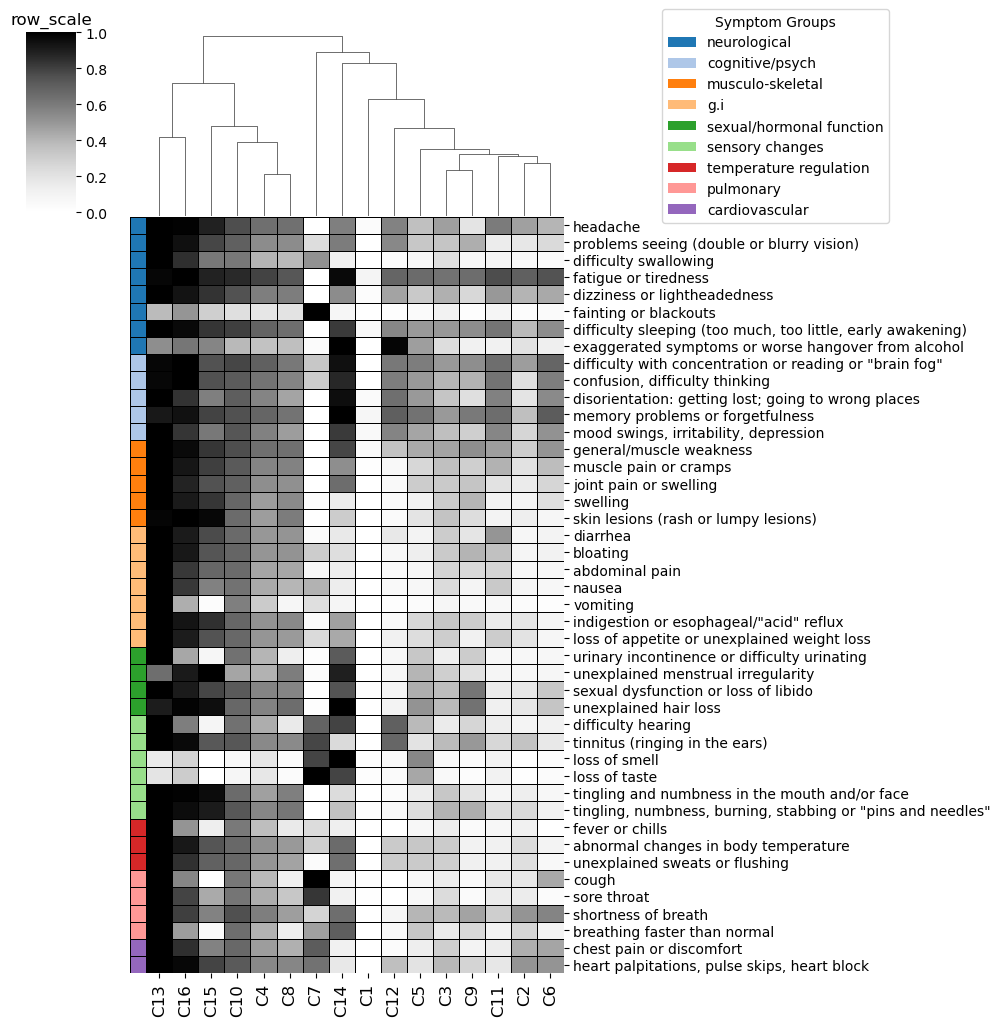

In [66]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

In [67]:
# printing top organ systems in cluster order
for key in [13, 16, 15, 10, 4, 8, 7, 14, 1, 12, 5, 3, 9, 11, 2, 6]: 
    print(key, cluster_toporgans_dict[key])

13 ['g.i', 'sexual/hormonal function', 'temperature regulation']
16 ['g.i', 'neurological', 'sensory changes']
15 ['musculo-skeletal', 'sensory changes', 'sexual/hormonal function']
10 ['g.i', 'sexual/hormonal function', 'temperature regulation']
4 ['g.i', 'sexual/hormonal function', 'temperature regulation']
8 ['musculo-skeletal', 'sensory changes', 'sexual/hormonal function']
7 ['neurological', 'pulmonary', 'sensory changes']
14 ['neurological', 'sensory changes', 'sexual/hormonal function']
1 ['cognitive/psych', 'neurological', 'sensory changes']
12 ['cognitive/psych', 'neurological', 'sensory changes']
5 ['neurological', 'sensory changes', 'sexual/hormonal function']
3 ['musculo-skeletal', 'neurological', 'sensory changes']
9 ['g.i', 'musculo-skeletal', 'sexual/hormonal function']
11 ['cognitive/psych', 'g.i', 'neurological']
2 ['cardiovascular', 'neurological', 'pulmonary']
6 ['cardiovascular', 'cognitive/psych', 'pulmonary']


In [68]:
endo_dict = {1:0, 2:1, 3:2, 4:3, 5:2, 6:1, 7:4, 8:3, 9:2, 10:3, 11:1, 12:2, 13:3, 14:4, 15:3, 16:3} # sinai_n825

In [69]:
severity

,level_0,index,sum,cluster,color
0,0,C1,0.572607,1,green
1,1,C2,9.499710,2,yellow
2,11,C12,11.099660,12,yellow
3,5,C6,11.187363,6,yellow
4,6,C7,11.558083,7,yellow
5,10,C11,11.921555,11,yellow
6,8,C9,12.191753,9,yellow
7,4,C5,13.127195,5,yellow
8,2,C3,13.557691,3,yellow
9,7,C8,19.682539,8,red


# Final cluster assignments

In [70]:
surveys = pd.read_csv("data_cleaned/UCSF_2_4_25_most_recent_surveys_100_n825.csv")
del surveys["currentsymptoms_45"]
del surveys["currentsymptoms_46"]
surveys = surveys.rename(columns = {"comorb_selfreport_v2___13": "comorb_selfreport_13"})
patients = surveys.copy()
patients["cluster"] = clusters
dictionary = dict(zip(severity["cluster"], severity["color"]))
patients["severity"] = [dictionary[val] for val in patients["cluster"]]
dictionary = {"green": "mild", "yellow": "moderate", "red": "severe"}
patients["severity"] = [dictionary[val] for val in patients["severity"]]
dictionary = dict(zip(severity["cluster"], severity["sum"]))
patients["severity_score"] = [dictionary[val] for val in patients["cluster"]]
patients["top6symptoms"] = [cluster_topsymptoms_dict[val] for val in patients["cluster"]]
patients["top3organs"] = [cluster_toporgans_dict[val] for val in patients["cluster"]]
patients["endotype"] = ["E" + str(endo_dict[val]) for val in patients["cluster"]]
columns = ["record_id", 'sex', 'cluster', 'endotype', 'severity', 'severity_score', 'top6symptoms', 'top3organs']
patients = patients[columns]
patients.columns = ["Subject_ID", "Sex", "Cluster_ID", "Endotype_ID (defined by organ systems involved)", 
                    "Severity_Group (predicted by ML)", "severity_score", "Top6_signature_symptoms", "Top3_organ_systems"]
# patients.to_csv(f"cluster_assignments_sinai_n{n}_{number_of_topics}topics_{n_clusters}clusters_v1.csv", index = False)
patients

,Subject_ID,Sex,Cluster_ID,Endotype_ID (defined by organ systems involved),Severity_Group (predicted by ML),severity_score,Top6_signature_symptoms,Top3_organ_systems
0,2,M,2,E1,moderate,9.499710,"[chest pain or discomfort, heart palpitations,...","[cardiovascular, neurological, pulmonary]"
1,3,F,1,E0,mild,0.572607,"[fatigue or tiredness, loss of smell, loss of ...","[cognitive/psych, neurological, sensory changes]"
2,7,M,4,E3,severe,21.746250,"[vomiting, fever or chills, urinary incontinen...","[g.i, sexual/hormonal function, temperature re..."
3,8,F,1,E0,mild,0.572607,"[fatigue or tiredness, loss of smell, loss of ...","[cognitive/psych, neurological, sensory changes]"
4,9,F,8,E3,severe,19.682539,"[unexplained menstrual irregularity, tingling ...","[musculo-skeletal, sensory changes, sexual/hor..."
...,...,...,...,...,...,...,...,...
820,1272,F,1,E0,mild,0.572607,"[fatigue or tiredness, loss of smell, loss of ...","[cognitive/psych, neurological, sensory changes]"
821,1273,M,2,E1,moderate,9.499710,"[chest pain or discomfort, heart palpitations,...","[cardiovascular, neurological, pulmonary]"
822,1274,M,9,E2,moderate,12.191753,"[sexual dysfunction or loss of libido, unexpla...","[g.i, musculo-skeletal, sexual/hormonal function]"
823,1275,F,3,E2,moderate,13.557691,"[tingling, numbness, burning, stabbing or ""pin...","[musculo-skeletal, neurological, sensory changes]"


In [71]:
)

SyntaxError: unmatched ')' (687023194.py, line 1)

# Subclustering

In [ ]:
def sorting(clusters): 
    # Sorting by cluster sizes
    dictionary = sorted(dict(Counter(clusters)).items(), key=lambda x:x[1])
    dictionary.reverse()
    # [(1, 183), (3, 94), (5, 88), (9, 68), (2, 59), (8, 52), (7, 50), (4, 39), (6, 36)]
    mapping = dict(zip([val[0] for val in dictionary], np.unique(clusters))) # new:original
    # {1: 1, 3: 2, 5: 3, 9: 4, 2: 5, 8: 6, 7: 7, 4: 8, 6: 9}
    clusters = [mapping[val] for val in clusters]
    return clusters

In [ ]:
cluster_df = pd.DataFrame()
cluster = 1
print(cluster)
subset = patient_by_symptom[patient_by_symptom["cluster"] == cluster]
topsymptoms = list(cluster_topsymptoms["C" + str(cluster)])
subset = subset[topsymptoms]
method = "KMeans"
for i in range(2, 11): 
    method_ = method + "_" + str(i)
    clustering = sklearn.cluster.KMeans(n_clusters = i, random_state = 916).fit(subset)
    cluster_df[method_] = sorting(clustering.labels_ + 1)
    print(len(np.unique(cluster_df[method_])))
    print(dict(Counter(cluster_df[method_])))
cluster_df

In [ ]:
from sklearn.metrics import silhouette_score 
import matplotlib.pyplot as plt

# Getting the best score per clustering method
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html
columns = []
dictionary = {}
silhouette_scores = pd.DataFrame()
for col in cluster_df.columns: 
    silhouette_avg = silhouette_score(subset, cluster_df[col])
    key = col.split("_")[0]
    if key not in dictionary or dictionary[key][1] < silhouette_avg: 
        dictionary[key] = (col, silhouette_avg)
    score = silhouette_score(subset, cluster_df[col])
    silhouette_scores = pd.concat([silhouette_scores, pd.DataFrame({"cluster": [col], "score": [score]})])
silhouette_scores

In [ ]:
n_clusters = 2
print(max(silhouette_scores["score"]))
a = plt.scatter(range(2, 11), silhouette_scores["score"])
a = plt.title(method)
a = plt.plot([n_clusters, n_clusters], [0, 0.5], color = "red")

In [ ]:
subset_norm = subset/subset.sum(1)[:,np.newaxis]
subset_norm = preprocessing.normalize(subset)
UMAP = umap.UMAP(metric='euclidean', n_neighbors=10, random_state=916)
embedding = UMAP.fit_transform(subset_norm)

In [ ]:
n_clusters = 2
clusters = get_clusters(clustering_method, n_clusters, subset)
# clusters = get_clusters(clustering_method, n_clusters, embedding)
print(Counter(clusters))
plot_clusters(clusters, embedding, f"{clustering_method} {n_clusters} clusters", colors, None, None)

In [ ]:
# topic_proportions
subset_ = subset.copy()
subset_["cluster"] = clusters
print(subset_["cluster"].value_counts())
subset_.groupby("cluster").mean()

In [ ]:
n_clusters = 2
# clusters = get_clusters(clustering_method, n_clusters, subset)
clusters = get_clusters(clustering_method, n_clusters, embedding)
print(Counter(clusters))
plot_clusters(clusters, embedding, f"{clustering_method} {n_clusters} clusters", colors, None, None)

In [ ]:
# embedding
subset_ = subset.copy()
subset_["cluster"] = clusters
print(subset_["cluster"].value_counts())
subset_.groupby("cluster").mean()